In [2]:
import numpy as np
import struct
import random

from array import array
from os.path import join

import matplotlib.pyplot as plt
import pandas as pd

#from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from openTSNE.affinity import PerplexityBasedNN

from scipy.sparse import csr_matrix
from scipy.io import mmwrite

import scipy.sparse

import os

import scanpy as sc

#print("numpy:", np.__version__)
#print("matplotlib:", matplotlib.__version__)
#print("pandas:", pd.__version__)
#print("scikit-learn:", sklearn.__version__)
#print("scipy:", scipy.__version__)
#print("Pillow:", PIL.__version__)
#print("openTSNE:", openTSNE.__version__)

In [3]:
#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath, test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)        

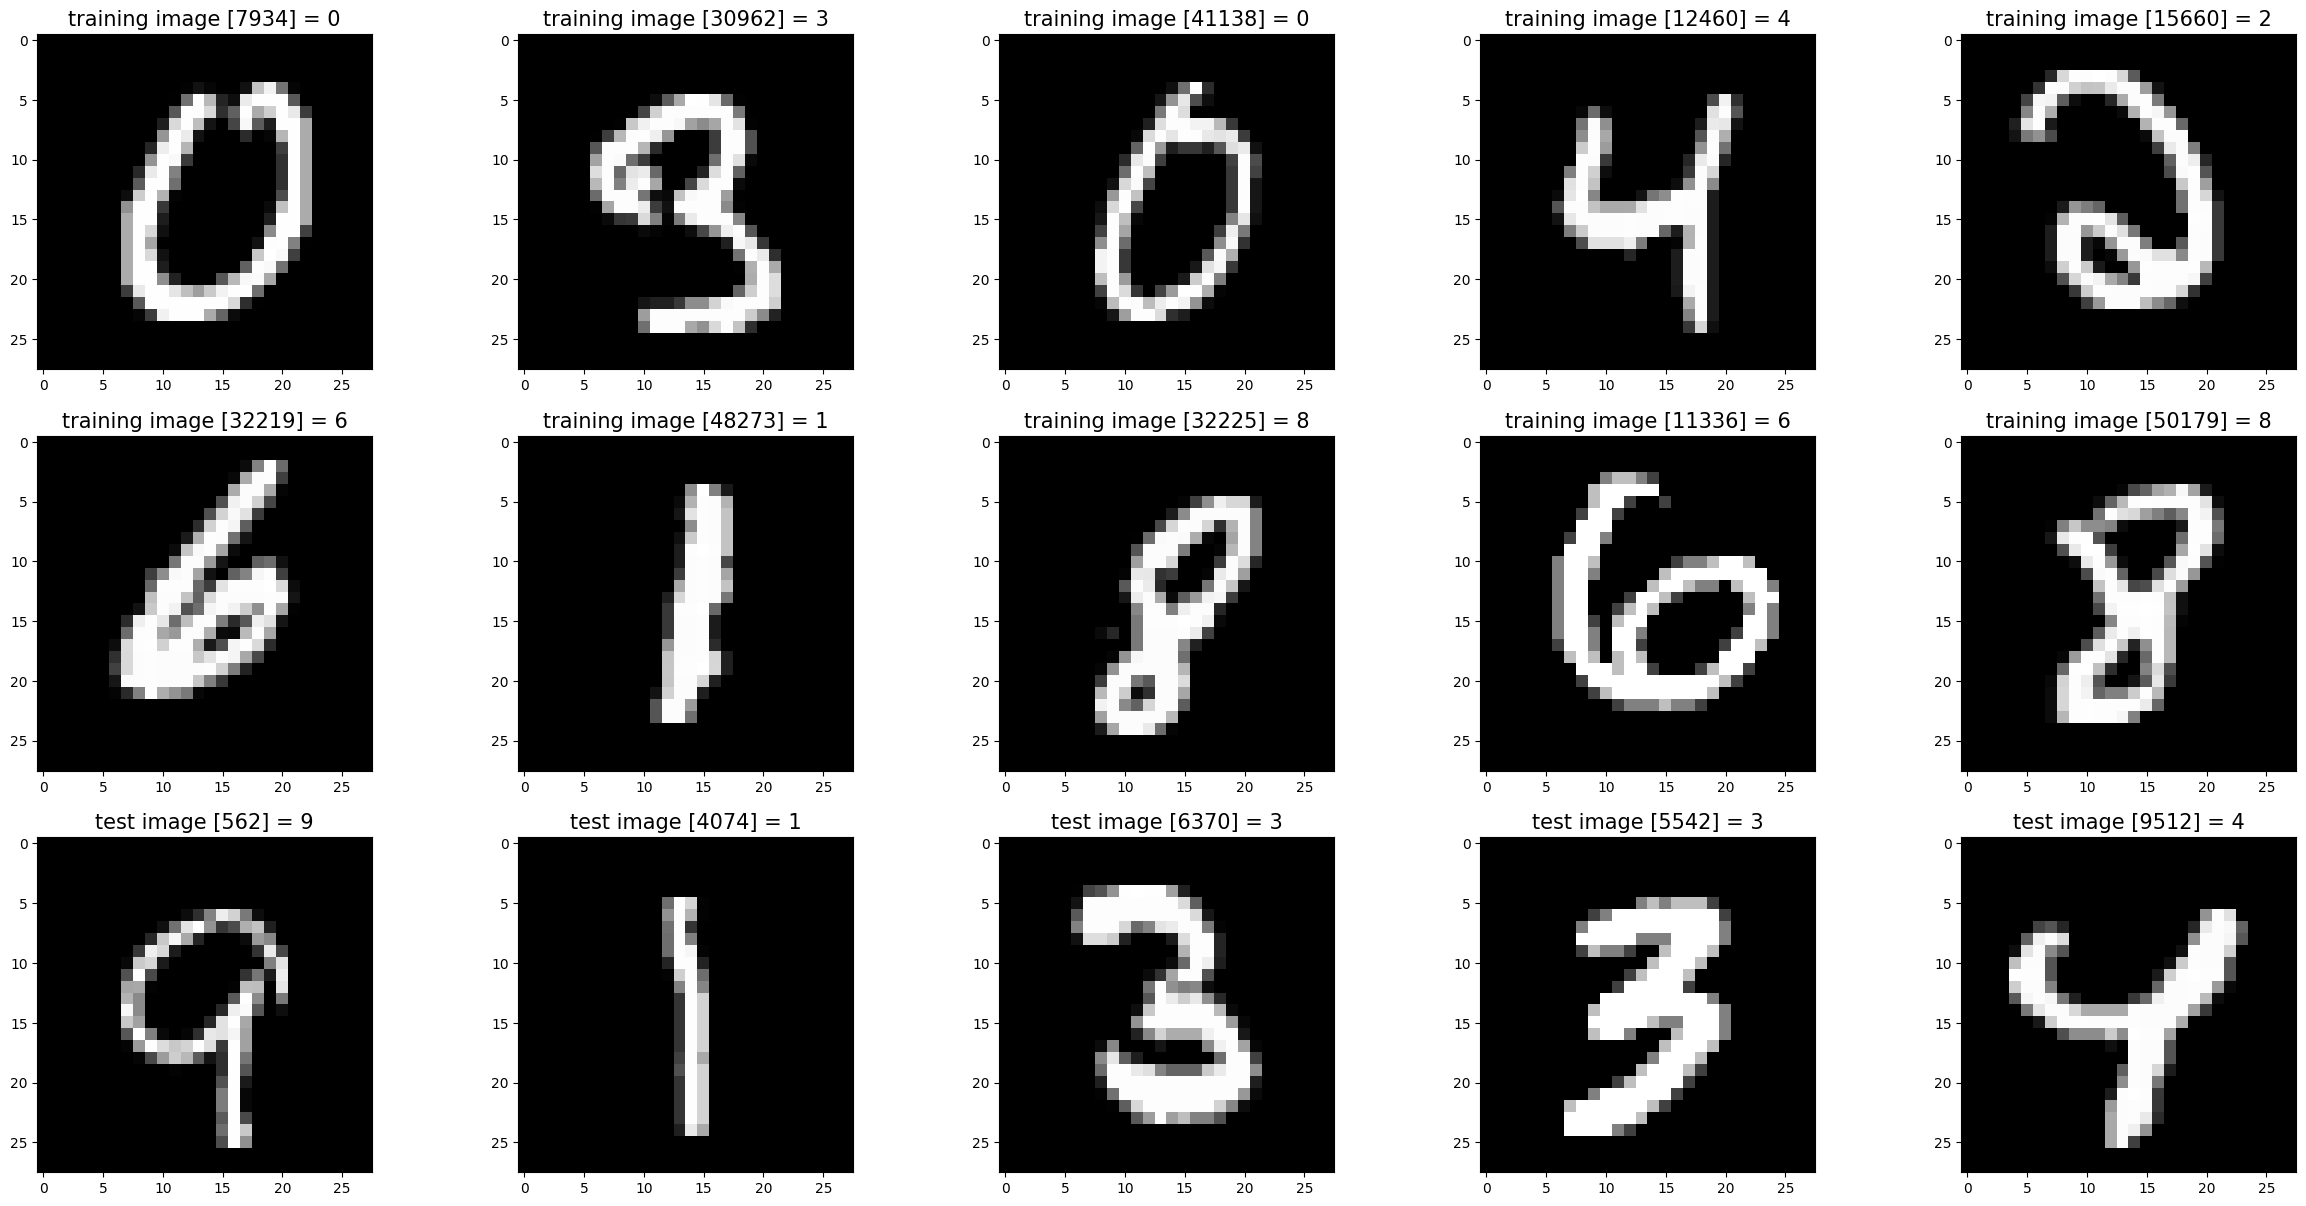

In [4]:
#
# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline



#
# Set file paths based on added MNIST Datasets
#
#input_path = './input'
input_path = './TSNEdataInput'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images.idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels.idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images.idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels.idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 60000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [14]:


input_path = './TSNEdataInput'
large_data_path = join(input_path, "1M_neurons_filtered_gene_bc_matrices_h5.h5")
adata = sc.read_10x_h5(large_data_path)

# Make variable names unique (recommended)
adata.var_names_make_unique()

# Check what you loaded
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")
print(adata)

# View the first few cells and genes
print("\nFirst 5 cell barcodes:")
print(adata.obs_names[:5])

print("\nFirst 5 genes:")
print(adata.var_names[:5])

Number of cells: 1306127
Number of genes: 27998
AnnData object with n_obs × n_vars = 1306127 × 27998
    var: 'gene_ids'

First 5 cell barcodes:
Index(['AAACCTGAGATAGGAG-1', 'AAACCTGAGCGGCTTC-1', 'AAACCTGAGGAATCGC-1',
       'AAACCTGAGGACACCA-1', 'AAACCTGAGGCCCGTT-1'],
      dtype='object')

First 5 genes:
Index(['Xkr4', 'Gm1992', 'Gm37381', 'Rp1', 'Rp1-1'], dtype='object')


C:\Users\Lucas\AppData\Local\Programs\Python\Python38\lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Index([], dtype='object')


KeyError: 'X_pca'

In [17]:
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata)

In [19]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="cell_ranger"
)

adata = adata[:, adata.var.highly_variable]

In [8]:
#sc.pp.scale(adata, max_value=10)#we can ignore this?

C:\Users\Lucas\anaconda3\envs\tsneEnv\lib\site-packages\scanpy\preprocessing\_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
C:\Users\Lucas\anaconda3\envs\tsneEnv\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
sc.tl.pca(
    adata,
    n_comps=50,
    svd_solver="randomized"
)

In [21]:
print(adata.obsm["X_pca"].shape)

(1306127, 50)


In [23]:
label_columns = adata.obs.select_dtypes(include=['object', 'category']).columns
print(label_columns)

Index([], dtype='object')


In [6]:
adata.write("./TSNEdataInput/adata_pca50_sparse.h5ad")
#adata = sc.read_h5ad("adata_pca50.h5ad")

In [6]:
adata = sc.read_h5ad("adata_pca50_sparse.h5ad")

NameError: name 'sc' is not defined

In [13]:
import openTSNE

x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

#print("x_train[0]: ", x_train[0])
#print("y_train[0]: ", y_test[0])

# set parameters
amount = 1000
perp = 30

# select random data
random_indices = np.random.choice(x_train.shape[0], size=amount, replace=False)
x_train_selection = x_train[random_indices]
y_train_selection = y_train[random_indices]
#print("selected data: ", x_train_selection.shape)
#print("selected labels: ", y_train_selection.shape)

# flatten the dimensions of the image matrix
x_train_selection_flat = x_train_selection.reshape(amount, -1)
#print("flattened data: ", x_train_selection_flat.shape)

# reduce the dimesnions of the image
pca = PCA(n_components=50)
x_train_selection_flat_reduced = pca.fit_transform(x_train_selection_flat)
#x_min = x_train_selection_flat_reduced.min()
#x_max = x_train_selection_flat_reduced.max()
#x_train_selection_flat_reduced = (x_train_selection_flat_reduced - x_min) / (x_max - x_min)
#print("selected data reduced dim: ", x_train_selection_flat_reduced.shape)
#print("first element from reduced: ", x_train_selection_flat_reduced[10])





# Check input before PerplexityBasedNN
print("Before PerplexityBasedNN:")
print(f"Shape: {x_train_selection_flat_reduced.shape}")
print(f"Has NaN: {np.isnan(x_train_selection_flat_reduced).any()}")
print(f"Has Inf: {np.isinf(x_train_selection_flat_reduced).any()}")
print(f"Min: {x_train_selection_flat_reduced.min()}")
print(f"Max: {x_train_selection_flat_reduced.max()}")

# Check for duplicate points
from scipy.spatial.distance import pdist
distances = pdist(x_train_selection_flat_reduced)
print(f"Min pairwise distance: {distances.min()}")
print(f"Number of zero distances: {np.sum(distances == 0)}")
print(f"Number of very small distances (<1e-10): {np.sum(distances < 1e-10)}")




print(type(x_train_selection_flat_reduced))
# create tsne and obtain the P matrix
#affinities = PerplexityBasedNN(x_train_selection_flat_reduced, perplexity=perp)
affinities = openTSNE.affinity.PerplexityBasedNN(
    x_train_selection_flat_reduced, 
    perplexity=perp,
    metric="euclidean",
    method="approx",  # or "exact"
    symmetrize=True,
    n_jobs=1,
    random_state=0,
    verbose=True  # This will show you what's happening
)
P_matrix = affinities.P
#P_matrix = csc_matrix(P_matrix)
#print("first non zero: ", P_matrix.data[0])

# store P matrix on disk
print(type(P_matrix))
print(P_matrix)
file_name_P = os.path.join("data", f"P_matrix_amount{amount}_perp{perp}.mtx")
file_name_P = "P_matrix_amount" +  str(amount) + "_perp" + str(perp) + ".mtx"
mmwrite(file_name_P, P_matrix)

# store labels on disk
#print(type(y_train_selection))
#print(y_train_selection)
file_name_L = os.path.join("data", f"label_amount{amount}_perp{perp}.bin")
file_name_L = "label_amount" +  str(amount) + "_perp" + str(perp) + ".bin"
with open(file_name_L, 'wb') as f:
    f.write(y_train_selection.tobytes())

Before PerplexityBasedNN:
Shape: (1000, 50)
Has NaN: False
Has Inf: False
Min: -1236.3729136943025
Max: 2253.6084988034227
Min pairwise distance: 233.80732123469053
Number of zero distances: 0
Number of very small distances (<1e-10): 0
<class 'numpy.ndarray'>
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 0.22 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.05 seconds
<class 'scipy.sparse._csr.csr_matrix'>
  (0, 988)	1.0031016246757203e-06
  (0, 951)	4.514178396035887e-07
  (0, 941)	4.556023028210841e-07
  (0, 935)	1.3583388312367223e-06
  (0, 917)	4.307791926065008e-07
  (0, 890)	8.288924632195568e-07
  (0, 771)	9.623356222511202e-07
  (0, 730)	1.0804749065321966e-06
  (0, 717)	2.8527333085428087e-07
  (0, 663)	2.0391023568544383e-06
  (0, 648)	6.224313642344158e-07
  (0, 588)	1.7289393581234687e-06
  (0, 501)	1.090559045494769e-06
  (0, 425)	1.0586026520972006e-06
  (0, 409)	2.394807307255945e-06
  

--------------------------------------------------------------------------------
TSNE(random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 0.23 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.05 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=200.00 for 250 iterations...
Iteration   50, KL divergence 3.3341, 50 iterations in 0.1422 sec
Iteration  100, KL divergence 3.3309, 50 iterations in 0.1231 sec
Iteration  150, KL divergence 3.3403, 50 iterations in 0.1160 sec
Iteration  200, KL divergence 3.3437, 50 iterations in 0.1166 sec
Iteration  250, KL divergence 3.3445, 50 iterations in 0.1171 sec
   --> Time elapsed: 0.62 seconds
===> Running optimization with exaggeration=1.00, lr=200.00 for 500 iterations.

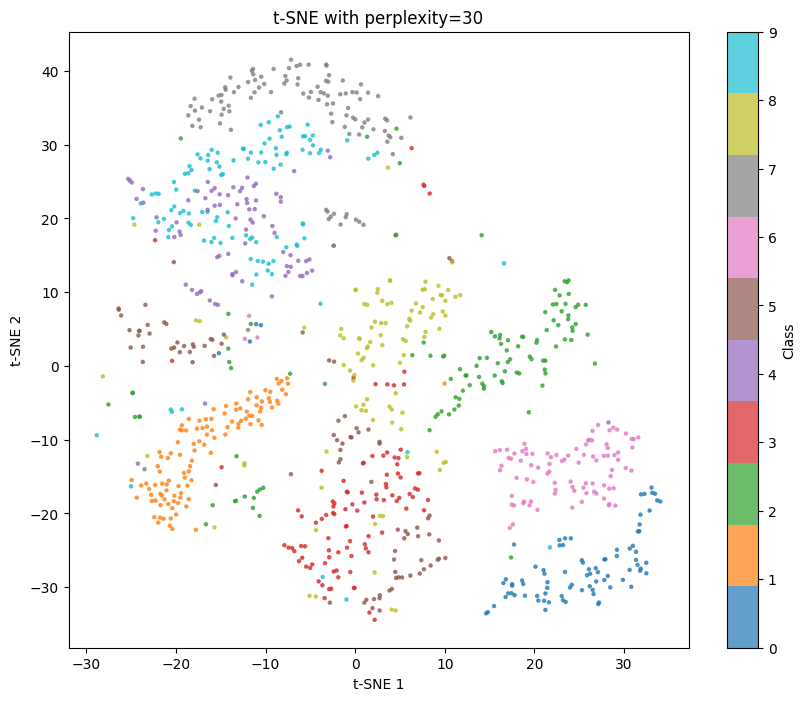

Embedding shape: (1000, 2)


In [6]:
from openTSNE import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=perp,
    random_state=42,
    verbose=True,
    n_jobs=1
)

# Fit and transform using your data
embedding = tsne.fit(x_train_selection_flat_reduced)

# Or if you want to use the P matrix directly:
# embedding = openTSNE.TSNEEmbedding(
#     np.random.randn(len(x_train_selection_flat_reduced), 2),  # initial positions
#     affinities=affinities,
#     random_state=42
# )
# embedding.optimize(n_iter=500, momentum=0.8)

# Visualize
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=y_train_selection, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(label='Class')
plt.title(f't-SNE with perplexity={perp}')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

print(f"Embedding shape: {embedding.shape}")

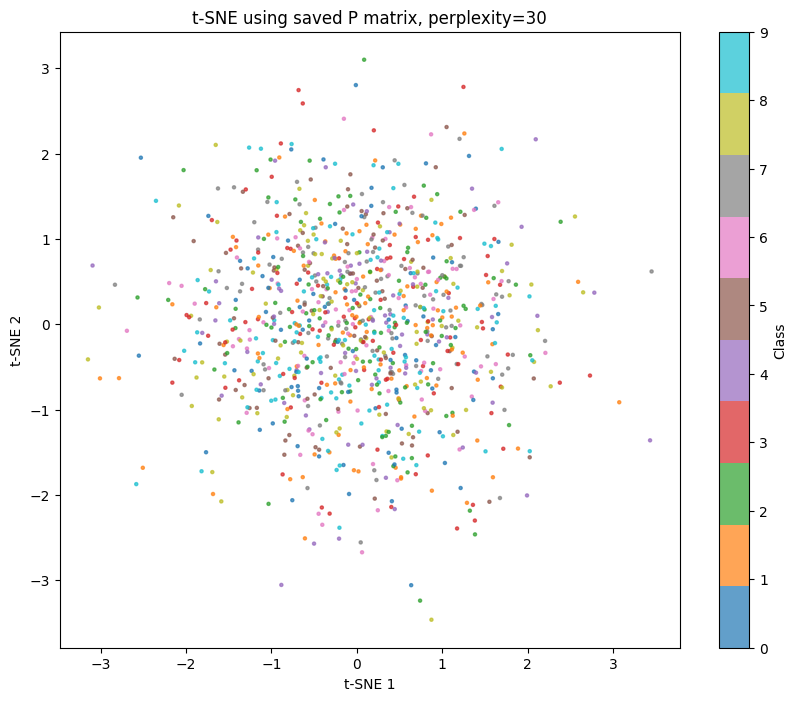

In [7]:
from openTSNE import TSNEEmbedding

# Use the affinities object you created earlier (which contains your P matrix)
embedding = TSNEEmbedding(
    np.random.randn(len(x_train_selection_flat_reduced), 2),  # random initial positions
    affinities=affinities,  # ← YOUR P matrix
    random_state=42
)

# Optimize
embedding.optimize(n_iter=500, momentum=0.8, exaggeration=12.0, learning_rate='auto')

# Visualize
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=y_train_selection, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(label='Class')
plt.title(f't-SNE using saved P matrix, perplexity={perp}')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

In [9]:
# Initialize t-SNE
#tsne = TSNE(n_components=2, random_state=42)  # 2D visualization
tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, n_iter=1000, random_state=42)


# Fit and transform the data
X_embedded = tsne.fit_transform(x_train_selection_flat_reduced)
print("embedding dim: ", X_embedded.shape)  # Should be (n_samples, 2)

embedding dim:  (1000, 2)


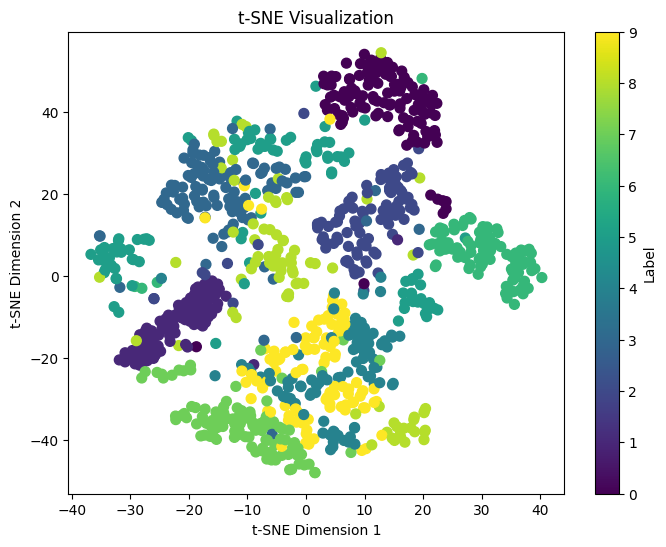

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y_train_selection, cmap='viridis', s=50)
plt.colorbar(label='Label')
plt.title('t-SNE Visualization')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()